In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [24]:
class Lor_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self, target_sr):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        eigenvalues = np.linalg.eigvals(w_res)
        current_sr = np.max(np.abs(eigenvalues))

        #TODO more on this
        if current_sr > 0: 
            w_res = w_res / current_sr * target_sr

        return w_res
        

    def init_input_weights_full(self, input_dim):
        w_in = np.random.uniform(-1, 1, (self.num_neurons, input_dim))
        mask = np.zeros((self.num_neurons, input_dim))
        input_neurons = np.random.choice(
            self.num_neurons,
            size=int(self.num_neurons * self.input_connectivity),
            replace=False
        )
        mask[input_neurons, :] = 1.0
        return w_in * mask

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def LIF_res(self, prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input_spikes + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk

In [25]:
def generate_lorenz(num_steps, dt=0.01, sigma=10, rho=28, beta=8/3):
    xyz = np.zeros((num_steps, 3))
    xyz[0] = [1.0, 1.0, 1.0]  # initial condition
    for t in range(num_steps - 1):
        x, y, z = xyz[t]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        xyz[t+1] = xyz[t] + dt * np.array([dx, dy, dz])
    return xyz

In [26]:
def train_readout_ridge(X_train, Y_train, alpha=1e-4):

    # X_train: (T, N)
    # Y_train: (T, 3)
    T, N = X_train.shape
    w_out = Y_train.T @ X_train @ np.linalg.inv(X_train.T @ X_train + alpha * np.eye(N))
    return w_out  # (3, N)

In [27]:
def nrmse(y_true, y_pred):
    # y_true, y_pred: (T, 3)
    error = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    scale = np.std(y_true, axis=0)
    return error / scale  # (3,) — one per coordinate

In [28]:
def normalize_lorenz(traj):
    mean = traj.mean(axis=0)       # (3,)
    std  = traj.std(axis=0)        # (3,)
    return (traj - mean) / std, mean, std

# Ridge regression

In [29]:
washout_steps = 200
train_steps   = 2000
test_steps    = 500
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.9,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']

res = Lor_reservoir(hp)

SR = 2.5

spectral_lambdas = [SR]

print(spectral_lambdas)

weight_scale = 1

score_tensor = []

num_trials = 10

for i in range(num_trials):
    print(10*"-")
    print(f"Trial {i}")

    score_arr = []

    for lam in spectral_lambdas:
        #print(10*"#")
        #print(f"for sr lambda {lam}")

        w_in_weights = res.init_input_weights_full(3) * weight_scale # (num_neurons, 3)
        w_res = res.init_weights(lam)

        lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)
        lorenz_norm, lorenz_mean, lorenz_std = normalize_lorenz(lorenz_traj)


        mem = np.zeros(num_neurons)
        spk = np.zeros(num_neurons)
        spk_rec = np.zeros((num_steps, num_neurons))
        mem_rec = np.zeros((num_steps, num_neurons))

        #print(f"ready to sim")

        for t in range(num_steps):

            I = w_in_weights @ lorenz_norm[t] # (100, )

            mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
            spk_rec[t] = spk
            mem_rec[t] = mem


        X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
        Y_train = lorenz_norm[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)

        X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
        Y_test = lorenz_norm[washout_steps + train_steps+1 : total_steps]  # (T, 3)

        #print(f"ready to train")

        # train
        w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)

        # predict
        Y_pred = (w_out @ X_test.T).T   # (T, 3)

        Y_pred_denorm = Y_pred * lorenz_std + lorenz_mean
        Y_test_denorm = Y_test * lorenz_std + lorenz_mean

        # score
        scores = nrmse(Y_test_denorm, Y_pred_denorm)

        score_arr.append(scores)

    score_tensor.append(score_arr) # (num_trials, num_lambdas, 3)

# average over trials
avg_scores = np.mean(score_tensor, axis=0)  # (num_lambdas, 3)
std_scores = np.std(score_tensor, axis=0)   # (num_lambdas, 3)

print("-"*10)

print(f"final score for SR {SR}: {avg_scores[0]}")

[2.5]
----------
Trial 0
----------
Trial 1
----------
Trial 2
----------
Trial 3
----------
Trial 4
----------
Trial 5
----------
Trial 6
----------
Trial 7
----------
Trial 8
----------
Trial 9
----------
final score for SR 2.5: [0.24502017 0.37752822 0.45160988]


# Online Learning with Eligibility Traces (simplified)

## Overview

This notebook explores online, bio-plausible learning for the readout weights, as an alternative to the offline ridge regression approach. Instead of collecting all reservoir states and solving for $W_{out}$ in one shot, the readout is updated incrementally at each timestep using a prediction error signal and an eligibility trace over recent spike activity.

The update rule is inspired by e-prop, a biologically plausible gradient approximation for recurrent spiking networks, but significantly simplified: only the readout weights $W_{out}$ are updated, and the reservoir itself remains fixed.

## Eligibility Trace

Rather than using the raw spike $s[t]$ directly for each update, an eligibility trace $e[t]$ accumulates a decaying memory of recent presynaptic activity:

$$e[t] = \gamma \cdot e[t-1] + s[t]$$

- $\gamma \in [0, 1)$ — trace decay factor
- $s[t]$ — current spike vector from the reservoir

This gives each synapse a short-term memory of how recently and how often its presynaptic neuron fired, which is what makes the learning rule temporally local and biologically motivated.

## Readout Update

At each timestep, the readout predicts the next point on the trajectory, and the error is used to update $W_{out}$ immediately:

$$\hat{y}[t] = W_{out} \cdot s[t]$$

$$\delta[t] = \hat{y}[t] - y[t+1]$$

$$W_{out} \leftarrow W_{out} - \eta \cdot \delta[t] \otimes e[t]$$

- $\hat{y}$ — predicted next state (3-dimensional)
- $\delta$ — prediction error
- $\eta$ — learning rate
- $\otimes$ — outer product

This is essentially online gradient descent on the mean squared prediction error, where the gradient with respect to $W_{out}$ is approximated using the eligibility trace instead of the exact spike activity. The trace introduces a temporal smoothing effect that stabilizes learning under noisy spiking activity.

<span style="color:yellow">Note that this is a simplified variant: a full e-prop implementation would also propagate learning signals through the recurrent weights using approximated gradients, which is not done here.</span>

In [36]:
washout_steps = 200
train_steps   = 10000
test_steps    = 1000
total_steps   = washout_steps + train_steps + test_steps

hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}

N = hp['num_neurons']

SR = 2.5

res = Lor_reservoir(hp)
w_res = res.init_weights(SR)
w_in_weights = res.init_input_weights_full(3) * 1 # (N, 3)

lorenz_traj = generate_lorenz(total_steps + 1, dt=0.01)  # +1 so t+1 is always valid
lorenz_norm, lorenz_mean, lorenz_std = normalize_lorenz(lorenz_traj)

w_out   = np.zeros((3, N))
e_trace = np.zeros(N)          # single shared trace over presynaptic activity

lr    = 1e-4                   # start conservative
gamma = 0.8                    # eligibility trace decay

mem = np.zeros(N)
spk = np.zeros(N)

train_errors = []

for t in range(washout_steps + train_steps):
    I = w_in_weights @ lorenz_norm[t]
    mem, spk = res.LIF_res(mem, spk, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])

    if t < washout_steps:
        continue

    y_pred = w_out @ spk                    # (3,)
    y_true = lorenz_norm[t + 1]             # (3,)
    error  = y_pred - y_true                # (3,)

    e_trace = gamma * e_trace + spk         # (N,)

    w_out -= lr * np.outer(error, e_trace)  # (3, N)

    train_errors.append(np.mean(error**2))

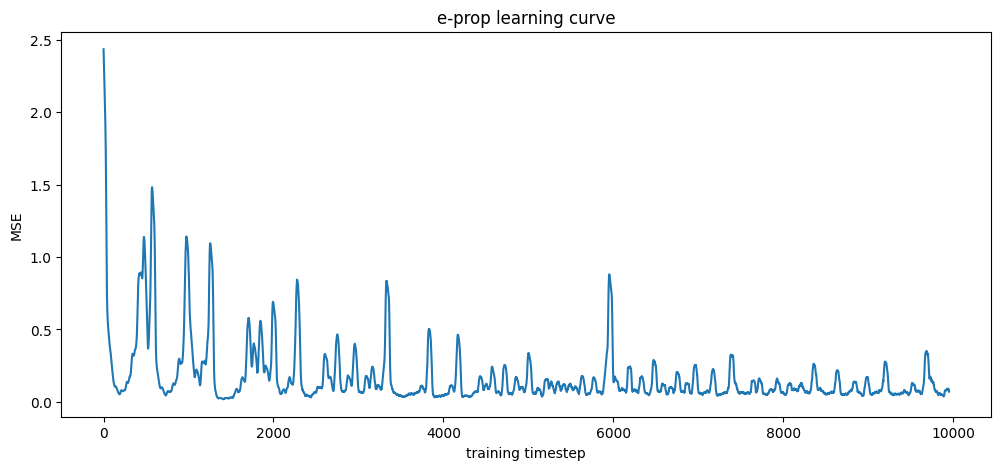

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(np.convolve(train_errors, np.ones(50)/50, mode='valid'))  # smoothed
plt.xlabel('training timestep')
plt.ylabel('MSE')
plt.title('e-prop learning curve')
plt.show()

In [38]:
test_errors = []
y_preds = []
y_trues = []

for t in range(washout_steps + train_steps, total_steps):
    I = w_in_weights @ lorenz_norm[t]
    mem, spk = res.LIF_res(mem, spk, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])

    y_pred = w_out @ spk
    y_true = lorenz_norm[t + 1]

    y_preds.append(y_pred)
    y_trues.append(y_true)

Y_pred = np.array(y_preds)
Y_true = np.array(y_trues)

# denormalize
Y_pred_denorm = Y_pred * lorenz_std + lorenz_mean
Y_true_denorm = Y_true * lorenz_std + lorenz_mean

test_nrmse = nrmse(Y_true_denorm, Y_pred_denorm)  # (3,)
print("RSTDP test NRMSE:", test_nrmse)

RSTDP test NRMSE: [0.41095061 0.3867588  0.43859356]
